# Proyecto Integrador – RADAR  
## Avance 1: Análisis Exploratorio de Datos (EDA)

### RADAR  
**Reconocimiento Avanzado de Datos y Análisis de Retail**

Este notebook contiene el desarrollo correspondiente al Análisis Exploratorio de Datos (EDA) del proyecto RADAR, cuyo objetivo es analizar y comprender la estructura, calidad y comportamiento de los datos utilizados para identificar similitudes entre productos de e-commerce mediante técnicas de Inteligencia Artificial y Procesamiento de Lenguaje Natural (NLP).

El análisis se enfoca en identificar patrones, inconsistencias, valores faltantes, alta cardinalidad y posibles problemas de calidad en la información, así como en explorar relaciones relevantes entre variables antes de la etapa de modelado y generación de embeddings semánticos.

Además, este proceso permitirá definir estrategias de limpieza, normalización y preprocesamiento de datos para mejorar la capacidad de generalización y precisión del modelo de similitud de productos.

---

## Equipo

- **Ceja Rodríguez, Lázaro Romel** – A01795989  
- **Chávez Cervantes, Said** – A01114101  
- **Pérez Garza, Javier Alejandro** – A01284386  

---

In [266]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [267]:
import os
DIR = "/content/drive/MyDrive/Proyecto Integrador (RADAR)/Datos/"   # Se establece la ruta (carpeta) donde se sube el archivo descargado del estadístico
os.chdir(DIR)

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Parte 1**. Análisis de la información del catálogo de productos del retailer (Coppel)

In [269]:
# 1. BASE DE DATOS INTERNA (Catalogo de Coppel en la Categoría de Dama)
df_retailer = pd.read_csv('DataDamaJoven.csv', encoding='latin-1')

# Mostrar información inicial
print("\nDimensiones del dataset:")
print(df_retailer.shape)

print("\nPrimeros registros:")
display(df_retailer.head())


Dimensiones del dataset:
(15831, 10)

Primeros registros:


,Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final
0,300028,BOLSAS,DE MANO,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,10,JENNIFER LOPEZ,BROWN,SYNTHETIC 100%.,549,549
1,300039,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,10,SIN MARCA,CAFE,PVC 100 %.,2599,2599
2,300042,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,NEGRO,PVC 100 %.,2499,2499
3,300064,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,CAFE,PVC 100 %.,2499,2499
4,300069,BOLSAS,MOCHILA,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,10,CLX BY CHRISTIAN LACROIX,ASSORTED,POLYESTER 100%.,549,549


La Categoría de Ropa y Accesorios de Dama en Coppel cuenta con 15,831 códigos y 10 columnas con información descriptiva de cada una de ellos. Esta será la base para la comparativa contra la información de la competencia.

In [270]:
# Copia de seguridad de la base de datos
df_retailer_original = df_retailer.copy()

In [271]:
df_retailer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15831 entries, 0 to 15830
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Codigo        15831 non-null  int64 
 1   Clase         15831 non-null  object
 2   Familia       15831 non-null  object
 3   Descripcion   15831 non-null  object
 4   Tallas        15831 non-null  object
 5   Marca         15831 non-null  object
 6   Color         15831 non-null  object
 7   Composicion   15831 non-null  object
 8   Precio_reg    15831 non-null  int64 
 9   Precio_final  15831 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 1.2+ MB


1. Se utiliza el método `info()` del dataframe con la base de datos interna, para obtener el resumen de los tipos de datos. **En el dataframe de Coppel hay 3 columnas númericas (código, precio regular y precio publicado) y 7 cualitativas (con los datos descriptivos del producto).**

In [272]:
# Determinar el porcentaje de valores faltantes por columna en los datos del retailer.
l=len(df_retailer)
fpc=df_retailer.isna().sum()
df2=fpc/l*100
df2.to_frame()

,0
Codigo,0.0
Clase,0.0
Familia,0.0
Descripcion,0.0
Tallas,0.0
Marca,0.0
Color,0.0
Composicion,0.0
Precio_reg,0.0
Precio_final,0.0


In [273]:
# Separar las columnas numericas de las columnas de texto
dfn = df_retailer.select_dtypes(include=np.number).columns.tolist()
dfc = df_retailer.select_dtypes(exclude=np.number).columns.tolist()

# Análisis de variables numéricas

In [274]:
df_retailer.describe().T

,count,mean,std,min,25%,50%,75%,max
Codigo,15831.0,344238.497947,31173.156818,300028.0,315426.0,336584.0,372393.0,399997.0
Precio_reg,15831.0,667.386267,635.650661,69.0,269.0,399.0,799.0,3999.0
Precio_final,15831.0,571.056219,588.039170,9.0,199.0,335.0,699.0,3999.0


In [275]:
for column in dfn:
    print('Asimetría')
    print(column)
    print(df_retailer[column].skew())
    print('-' * 50)

Asimetría
Codigo
0.2814340191519392
--------------------------------------------------
Asimetría
Precio_reg
1.7108587062704739
--------------------------------------------------
Asimetría
Precio_final
1.829508579827535
--------------------------------------------------


In [276]:
for column in dfn:
    print('Curtosis')
    print(column)
    print(df_retailer[column].kurt())
    print('-' * 50)

Curtosis
Codigo
-1.3281083323328562
--------------------------------------------------
Curtosis
Precio_reg
2.070016278505747
--------------------------------------------------
Curtosis
Precio_final
2.7872621780593985
--------------------------------------------------


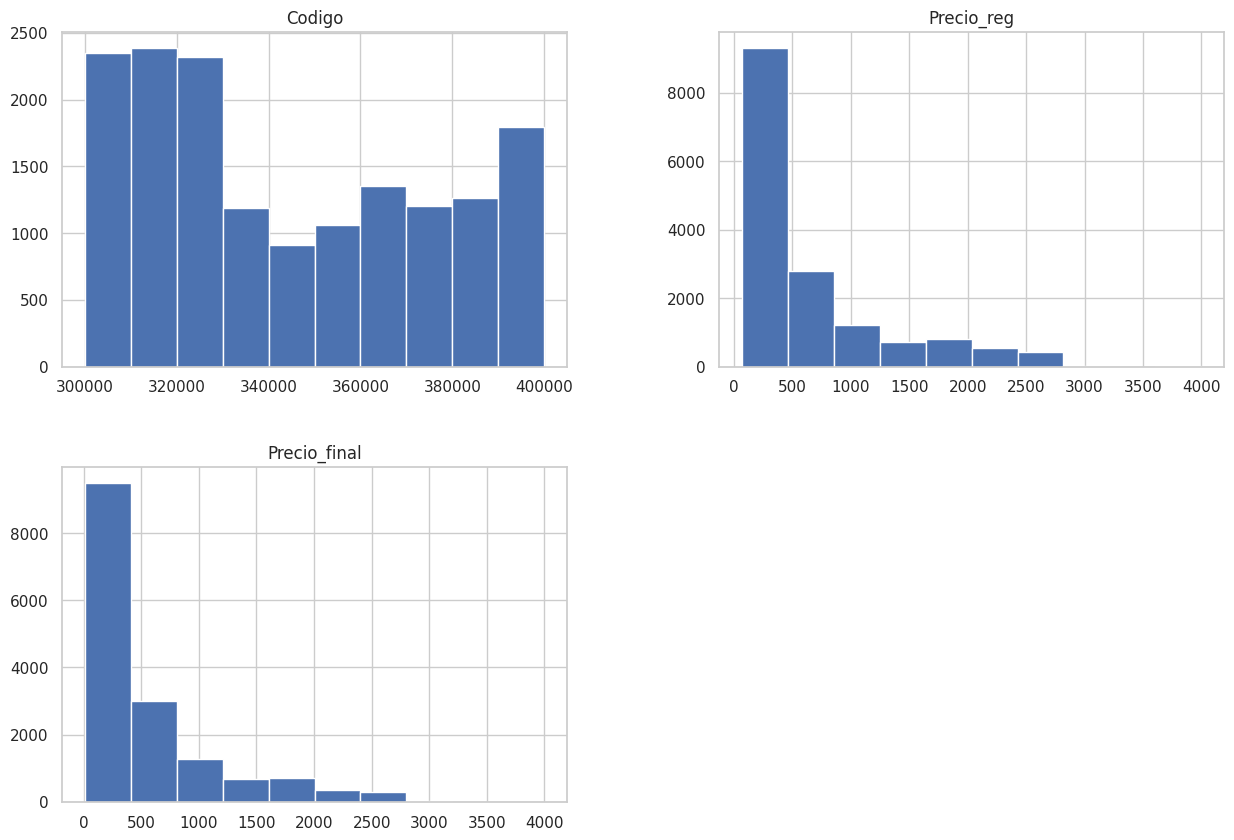

In [277]:
df_retailer.hist(figsize=(15,10))
plt.show()

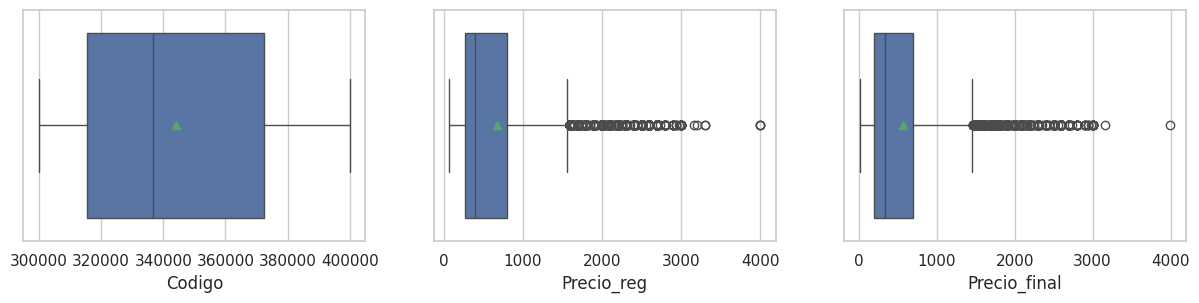

In [278]:
fig, axes = plt.subplots(1,3, figsize=(15,3))
axes = axes.ravel()
for col, ax in zip(df_retailer[dfn], axes):
  sns.boxplot(x=df_retailer[col], ax=ax, showmeans=True)
  ax.set(xlabel=f'{col}')

/tmp/ipykernel_8668/1412522243.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_retailer[col], labels=[f'{col}'])
/tmp/ipykernel_8668/1412522243.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_retailer[col], labels=[f'{col}'])
/tmp/ipykernel_8668/1412522243.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_retailer[col], labels=[f'{col}'])


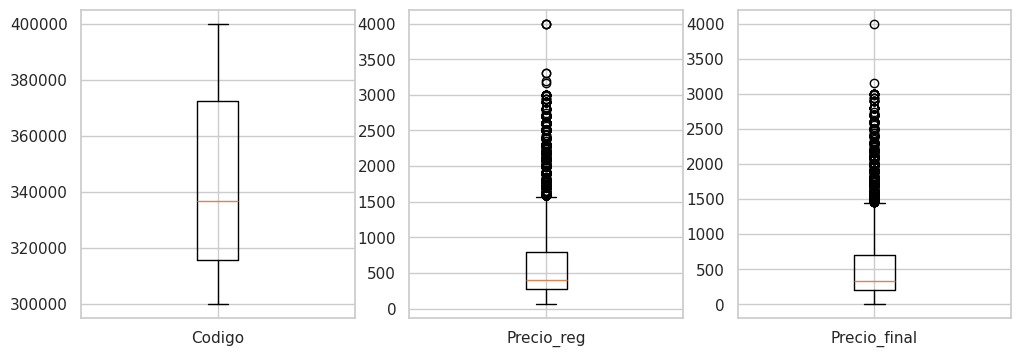

In [279]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes = axes.ravel()
for col, ax in zip(df_retailer[dfn], axes):
  ax.boxplot(df_retailer[col], labels=[f'{col}'])

2. Por la naturaleza del proyecto y la información que conforma la base de datos, las pocas variables numericas no se utilizarán cómo típicamente (para validación o entrenamiento o pronóstico). **Su uso sera meramente para clasificación (rangos de precios).**

# Análisis de variables de texto

In [280]:
df_retailer.describe(include = 'object').T

,count,unique,top,freq
Clase,15831,12,BOLSAS,3293
Familia,15831,78,CRUZADA,1299
Descripcion,15831,13880,FM TRAJE DE BAÑO PARA DAMA MARCA HOLLISTER,81
Tallas,15831,241,70/90/110/130,4317
Marca,15831,456,GUESS FACTORY,1326
Color,15831,201,NEGRO,2327
Composicion,15831,1897,POLIESTER 100%.,1191


In [281]:
dfr = df_retailer[df_retailer['Descripcion'] == 'ECOMM  BOLSA DE HOMBRO PARA DAMA']
dfr

,Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final
14378,391926,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,18 FOREVER,NEGRO,POLIURETANO 100%.,249,249
14389,392031,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,18 FOREVER,NEGRO,POLIURETANO 100%.,499,499
14395,392052,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,SAHARA,CAFE CHOCOLATE,POLIURETANO 100%.,399,399
14396,392054,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,STRONA,CAFE,POLIURETANO 100%.,499,499
14398,392061,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,STRONA,NEGRO,POLIURETANO 100%.,419,419
14399,392065,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,STRONA,CAFE,POLIURETANO 100%.,419,419
14401,392071,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,18 FOREVER,KHAKY,POLIURETANO 100%.,379,379
14402,392073,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,18 FOREVER,ROSA,POLIURETANO 100%.,379,379
14405,392076,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,SAHARA,BLANCO,POLIURETANO 100%.,419,419
14406,392077,BOLSAS,DE HOMBRO,ECOMM BOLSA DE HOMBRO PARA DAMA,10,SAHARA,NEGRO,POLIURETANO 100%.,419,419


In [282]:
df_retailer.value_counts().to_frame()

,,,,,,,,,,count
Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final,
399997,VESTIDO JUVENIL,VESTIDO CASUAL,FM VESTIDO CASUAL COLOR NARANJA,70/90/110/130,SIX AND SEVEN,NARANJA,RAYON 100 %.,199,59,1
300028,BOLSAS,DE MANO,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE CON HERRAJES DORADOS MARCA JLO,10,JENNIFER LOPEZ,BROWN,SYNTHETIC 100%.,549,549,1
300039,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLOR CAFE MEDIO,10,SIN MARCA,CAFE,PVC 100 %.,2599,2599,1
300042,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,NEGRO,PVC 100 %.,2499,2499,1
300064,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,CAFE,PVC 100 %.,2499,2499,1
...,...,...,...,...,...,...,...,...,...,...
300092,BLUSA JUVENIL,MODA MC,BLUSA MANGA CORTA CON ELASTICO EN MANGAS COLOR NEGRA,70/90/110,POOF NEW YORK,BLACK,COTTON 100%.,299,149,1
300091,BLUSA JUVENIL,MODA SM,ECOMM CHALECO CORTO DE MEZCLILLA AZUL DESLAVADO,70/90/110/130,BEBE,AZUL MEZCLILLA,ALGODON 100%.,459,459,1
300090,BOLSAS,CRUZADA,"BOLSA DAMA TIPO CARTERA CON ZIPPER QUE CUBRE TODO ALDEDOR. COLORES NEGRO, ROJO OSCURO, NEGRO CON DISEÑO Y AZUL CLARO.",10,FRENCH CONNECTION,ASSORTED,POLYESTER 100%.,349,149,1


In [283]:
for column in dfc:
    print(df_retailer[column].value_counts())
    print('-' * 50)

Clase
BOLSAS                        3293
BOTTOMS JUVENIL               2551
PLAYERA JUVENIL               2160
BLUSA JUVENIL                 1892
INVIERNO LIGERO               1652
VESTIDO JUVENIL                948
INVIERNO                       838
VERANO JUVENIL                 796
ACCESORIOS                     741
SOBREPRENDA                    414
PLAYA ROPA  Y TRAJE DE BAN     352
UNIFORMES COPPEL               194
Name: count, dtype: int64
--------------------------------------------------
Familia
CRUZADA                  1299
PLAYERA REGULAR MC       1036
DE HOMBRO                 873
VESTIDO CASUAL            810
DE MANO                   695
                         ... 
NOVEDADES                   5
CHAMARRA DELGADA            2
TRAJE BAÑO MATERNIDAD       1
GORRO                       1
GUANTES                     1
Name: count, Length: 78, dtype: int64
--------------------------------------------------
Descripcion
FM TRAJE DE BAÑO PARA DAMA MARCA HOLLISTER                

<Axes: xlabel='Clase', ylabel='count'>

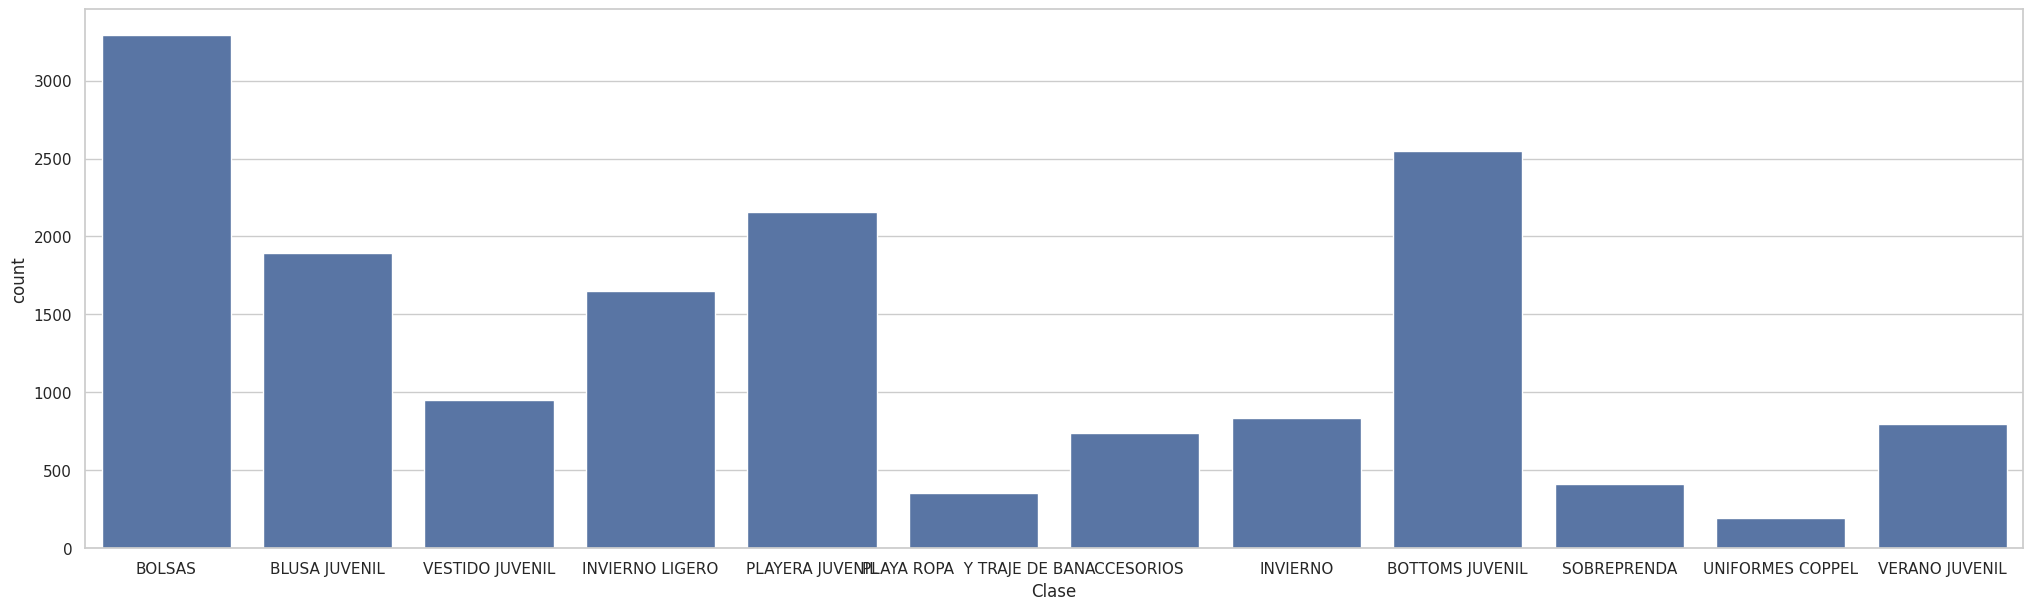

In [284]:
plt.figure(figsize = (25, 7))
sns.countplot(x='Clase', data=df_retailer)

/tmp/ipykernel_8668/1361908295.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8668/1361908295.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8668/1361908295.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8668/1361908295.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8668/1361908295.py:21: FutureWarning: 

P

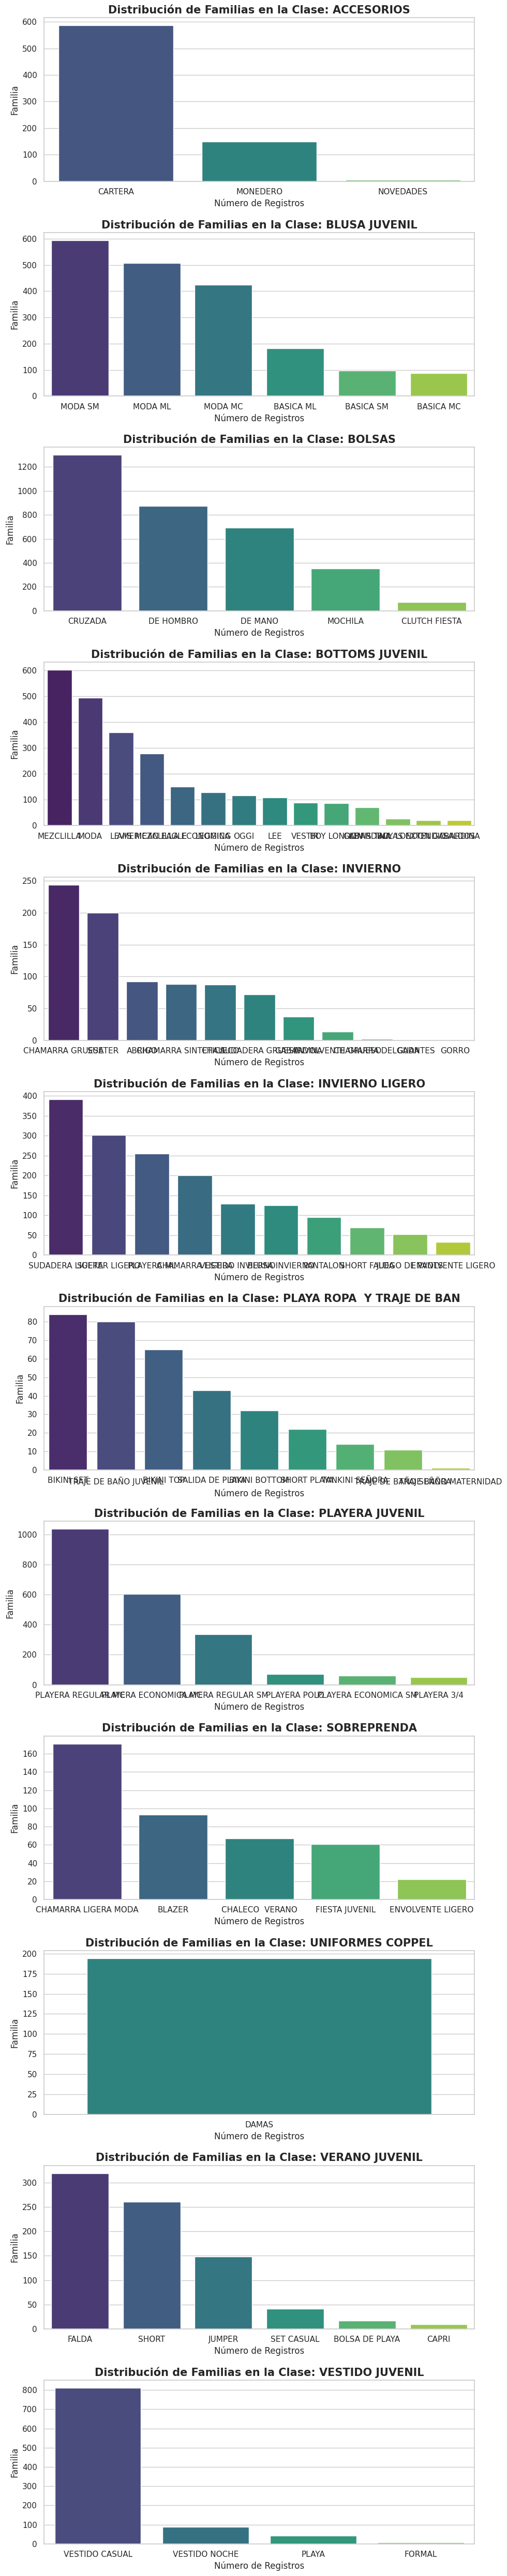

In [285]:
# 1. Preparación y Agregación
# Agrupamos para obtener el conteo exacto por jerarquía
df_counts = df_retailer.groupby(['Clase', 'Familia']).size().reset_index(name='Cantidad')

# 2. Visualización Dinámica
# Usamos un FacetGrid para separar por 'Clase' y que no se amontonen las Familias
sns.set_theme(style="whitegrid")

# Definimos el número de clases únicas para ajustar el tamaño
clases = df_counts['Clase'].unique()

# Creamos subplots: uno para cada clase
fig, axes = plt.subplots(len(clases), 1, figsize=(10, 50), sharex=False)

# Si solo hay una clase, axes no es una lista, la convertimos
if len(clases) == 1: axes = [axes]

for i, clase in enumerate(clases):
    data_plot = df_counts[df_counts['Clase'] == clase].sort_values('Cantidad', ascending=False)

    sns.barplot(
        x='Familia',
        y='Cantidad',
        data=data_plot,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f"Distribución de Familias en la Clase: {clase}", fontsize=15, fontweight='bold')
    axes[i].set_xlabel("Número de Registros")
    axes[i].set_ylabel("Familia")

plt.tight_layout()
plt.show()

3. El analisis de variables de texto indica que existen 1,951 (12%) descripciones repetidas, cuando en teoría no debería existir ninguna, por lo que esos registros se deben revisar y eliminar o ajustar. Además, demuestra que la Clase de Bolsas es la que tiene mayor cántidad de productos, en contraste con la menor cantidad de familias. **Con el objetivo de minimizar el volumen de información para una fase incial del proyecto y reducir la complejidad de la evaluación manual de los resultados obtenidos, a partir de esta parte del analisis se acotará la información correspondiente únicamente a ese grupo de artículos.**

# Análisis de correlación (bivariante y multivariante)

In [286]:
# Se eliminan los registros de las clases restantes para reducir la dimensionalidad de las bases de datos a modelar posteriormente
df_retailer = df_retailer[df_retailer['Clase'] == 'BOLSAS']

<Axes: xlabel='Familia', ylabel='Precio_final'>

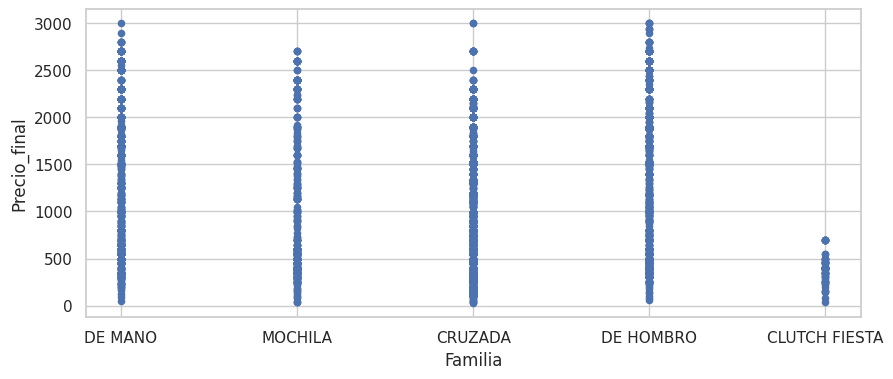

In [287]:
df_retailer.plot(kind='scatter',x='Familia',y='Precio_final', figsize=(10,4))

<Axes: >

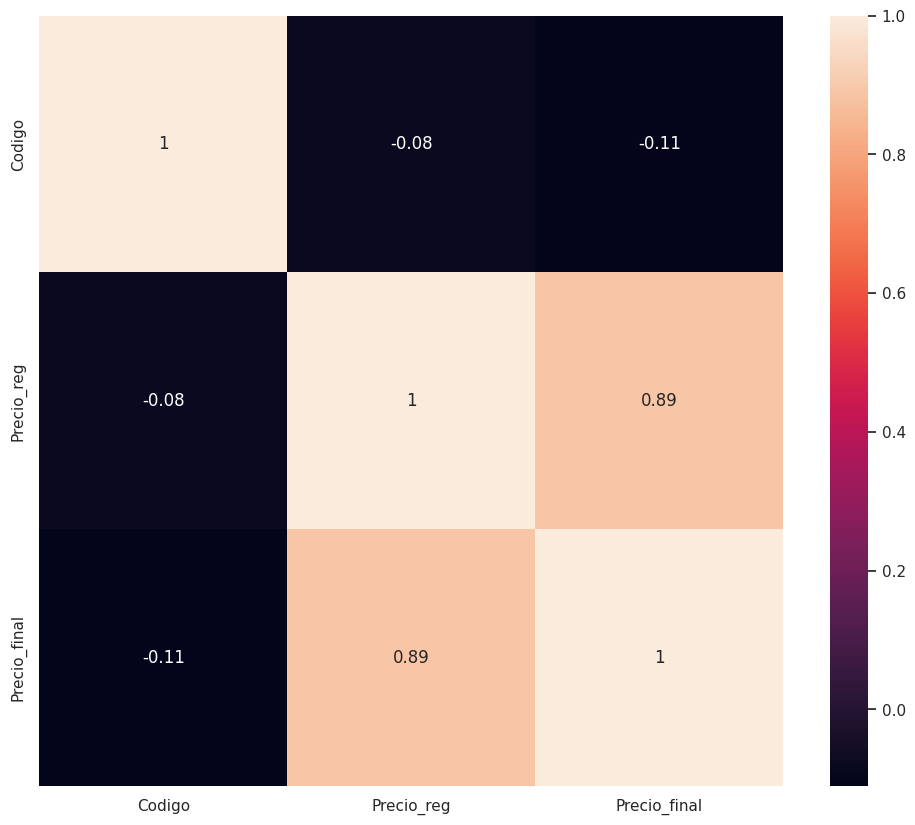

In [288]:
plt.figure(figsize = (12, 10))
sns.heatmap(round(df_retailer.corr(numeric_only=True),2), annot = True)

4. El analisis bivariable y multivariable también se vuelve poco relevante, ya que la naturaleza de la información relevante es la categorica. **En conclusión, el ananilis exploratorio de los datos de Coppel permitió acotar de manera estrategica el enfoque para comenzar a trabajar con un universo controlado de productos e ir escalando en complejidad a partir de este punto inicial.**

# **Parte 2**. Análisis de los datos de la competencia

In [289]:
# 2. BASE DE DATOS COMPETENCIA
# Se incluyen nombres y descripciones reales para validar la clasificación.
df_competencia = pd.read_csv('Liverpool_bolsa_completo.csv')

# Mostrar información inicial
print("\nDimensiones del dataset:")
print(df_competencia.shape)

print("\nPrimeros registros:")
display(df_competencia.head())


Dimensiones del dataset:
(446, 9)

Primeros registros:


,Pagina,Marca,Producto,Precio anterior,Precio actual,Reseñas / Rating,Colores,Link,Texto completo
0,2,1818,Bolsa tote para mujer,NaN,59900,NaN,Negro | Rosa | Lila | Verde,https://www.liverpool.com.mx/tienda/pdp/bolsa ...,1818 | Bolsa tote para mujer | $59900
1,6,ADIDAS ORIGINALS,Bolsa shoulder W L Ess Pouch para mujer,NaN,44900,NaN,Café,https://www.liverpool.com.mx/tienda/pdp/bolsa ...,ADIDAS ORIGINALS | Bolsa shoulder W L Ess Pouc...
2,9,ADOLFO DOMINGUEZ,Bolsa bandolera para mujer,359000,287200,NaN,Negro,https://www.liverpool.com.mx/tienda/pdp/bolsa ...,ADOLFO DOMINGUEZ | Bolsa bandolera para mujer ...
3,6,ADORN,Bolsa tote para mujer,49400,42956,1.0,Beige,https://www.liverpool.com.mx/tienda/pdp/bolsa ...,ADORN | Bolsa tote para mujer | $49400 | $4295...
4,10,ANGELOZANO,Bolsa tote Set Soraya de piel para mujer,518100,310800,NaN,Rosa | Azul | Rojo | Negro,https://www.liverpool.com.mx/tienda/pdp/bolsa ...,ANGELOZANO | Bolsa tote Set Soraya de piel par...


La base de datos con la información de la competencia está conformada por 446 productos, con 9 columnas con la información extraída del sitio web. El objetivo es utilizar la información relevante de cada uno de estos 446 productos e identificar el producto más similiar a los +3K de Coppel en cada uno de ellos.

In [290]:
# Copia de seguridad de la base de datos
df_competencia_original = df_competencia.copy()

In [291]:
df_competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pagina            446 non-null    int64  
 1   Marca             446 non-null    object 
 2   Producto          446 non-null    object 
 3   Precio anterior   204 non-null    object 
 4   Precio actual     446 non-null    object 
 5   Reseñas / Rating  249 non-null    float64
 6   Colores           437 non-null    object 
 7   Link              446 non-null    object 
 8   Texto completo    446 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 31.5+ KB


1. Se utiliza el método `info()` del dataframe con la base de datos interna, para obtener el resumen de los tipos de datos. **En el dataframe de la competencia hay 2 columnas numéricas (# de pagina y rating) y 7 cualitativas (con los datos descriptivos del producto y la url para consulta), sin embargo, 2 de las 7 columnas cuantitativas (Precio anterior y actual) deben ser transformadas a números para poder realizar operaciones aritméticas con ellas.**

In [292]:
# Eliminar los registros con más de 10 caracteres en las columnas Precio actual y Precio anterior (error en el scrapping)
df_competencia = df_competencia[df_competencia['Precio actual'].astype(str).str.len() < 10]
df_competencia = df_competencia[df_competencia['Precio anterior'].astype(str).str.len() < 10]
df_competencia.reset_index(drop=True, inplace=True)

In [293]:
# Convertir la columna Precio actual y Precio anterior de texto a número
df_competencia['Precio actual'] = df_competencia['Precio actual'].astype(float)
df_competencia['Precio anterior'] = df_competencia['Precio anterior'].astype(float)

In [294]:
# Se valida el cambio de formato
df_competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pagina            435 non-null    int64  
 1   Marca             435 non-null    object 
 2   Producto          435 non-null    object 
 3   Precio anterior   193 non-null    float64
 4   Precio actual     435 non-null    float64
 5   Reseñas / Rating  242 non-null    float64
 6   Colores           426 non-null    object 
 7   Link              435 non-null    object 
 8   Texto completo    435 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 30.7+ KB


In [295]:
df_competencia['Precio actual'] = df_competencia['Precio actual'] / 100
df_competencia['Precio anterior'] = df_competencia['Precio anterior'] / 100

In [296]:
# Determinar el porcentaje de valores faltantes por columna en los datos de la competencia.
l=len(df_competencia)
fpc=df_competencia.isna().sum()
df2=fpc/l*100
df2.to_frame()

,0
Pagina,0.000000
Marca,0.000000
Producto,0.000000
Precio anterior,55.632184
Precio actual,0.000000
Reseñas / Rating,44.367816
Colores,2.068966
Link,0.000000
Texto completo,0.000000


1. Se puede notar que, en este caso, los datos de la competencia tienen columnas con datos faltantes que hay que llenar, así como columnas que no aportan valor para el ejercicio. **Se deben igualar los precios anteriores al precio actual cuando existan vacíos (significa que no existe promoción) y eliminar las columnas de Reseñas / Ranking y Link que no contienen información relevante.**

In [297]:
# Eliminar las columnas 'Link' y 'Reseñas / Rating' que no se utilizara y contiene un alto porcentaje de valores faltantes.
# Igualar los precios anteriores con valores faltantes al precio actual
df_competencia.drop(columns=['Link'], inplace=True)
df_competencia.drop(columns=['Reseñas / Rating'], inplace=True)
df_competencia['Precio anterior'].fillna(df_competencia['Precio actual'], inplace=True)

/tmp/ipykernel_8668/3919326146.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_competencia['Precio anterior'].fillna(df_competencia['Precio actual'], inplace=True)


In [298]:
# Determinar el porcentaje de valores faltantes por columna en los datos de la competencia.
l=len(df_competencia)
fpc=df_competencia.isna().sum()
df2=fpc/l*100
df2.to_frame()

,0
Pagina,0.000000
Marca,0.000000
Producto,0.000000
Precio anterior,0.000000
Precio actual,0.000000
Colores,2.068966
Texto completo,0.000000


In [299]:
# Separar las columnas numericas de las columnas de texto
dfn = df_competencia.select_dtypes(include=np.number).columns.tolist()
dfc = df_competencia.select_dtypes(exclude=np.number).columns.tolist()

# Análisis de variables numéricas

In [300]:
df_competencia.describe().T

,count,mean,std,min,25%,50%,75%,max
Pagina,435.0,5.450575,2.914957,1.0,3.00,5.0,8.0,10.0
Precio anterior,435.0,1592.020437,878.011037,99.0,1093.50,1399.0,1994.5,10770.5
Precio actual,435.0,1376.391034,884.764006,99.0,662.37,1199.0,1799.0,8285.0


In [301]:
for column in dfn:
    print('Asimetría')
    print(column)
    print(df_competencia[column].skew())
    print('-' * 50)

Asimetría
Pagina
0.061819701815435904
--------------------------------------------------
Asimetría
Precio anterior
3.5401851860939737
--------------------------------------------------
Asimetría
Precio actual
2.029871742536206
--------------------------------------------------


In [302]:
for column in dfn:
    print('Curtosis')
    print(column)
    print(df_competencia[column].kurt())
    print('-' * 50)

Curtosis
Pagina
-1.2088524934053213
--------------------------------------------------
Curtosis
Precio anterior
29.020307066607558
--------------------------------------------------
Curtosis
Precio actual
9.859519530189983
--------------------------------------------------


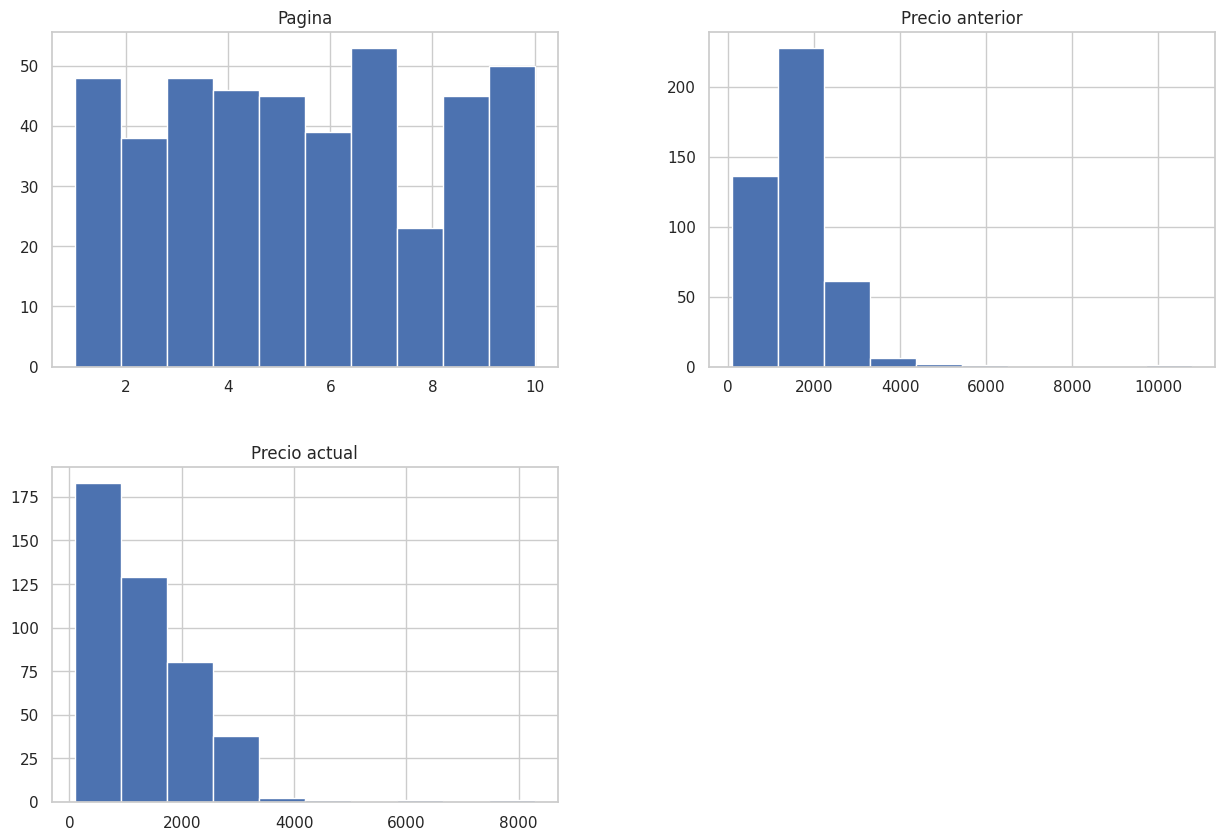

In [303]:
df_competencia.hist(figsize=(15,10))
plt.show()

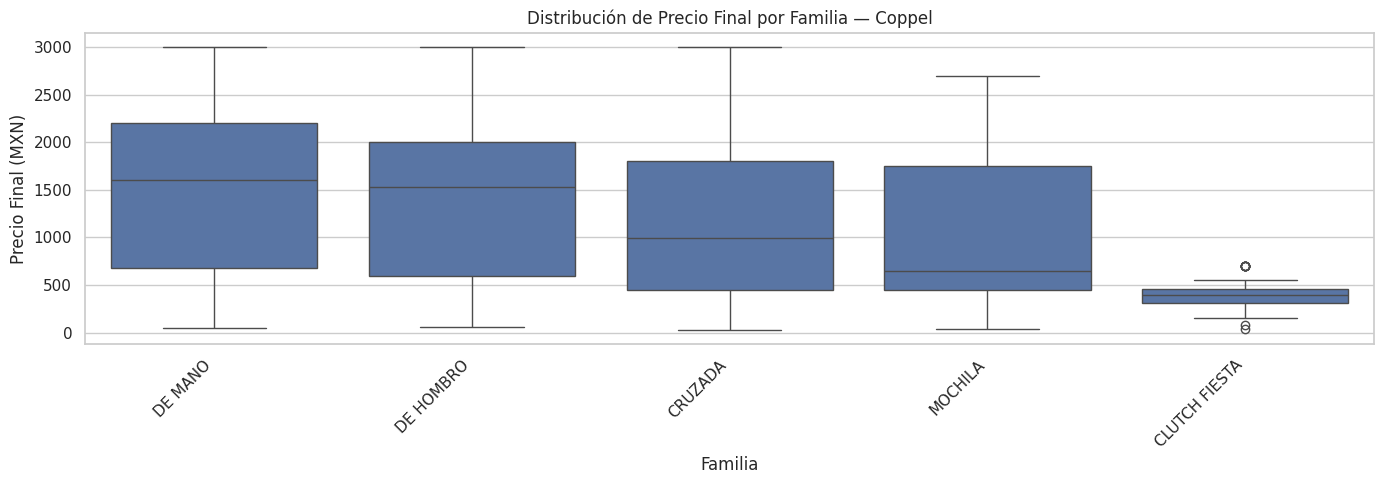

In [304]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='Familia', y='Precio_final', data=df_retailer,
            order=df_retailer.groupby('Familia')['Precio_final'].median().sort_values(ascending=False).index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Precio Final por Familia — Coppel')
plt.xlabel('Familia')
plt.ylabel('Precio Final (MXN)')
plt.tight_layout()
plt.show()

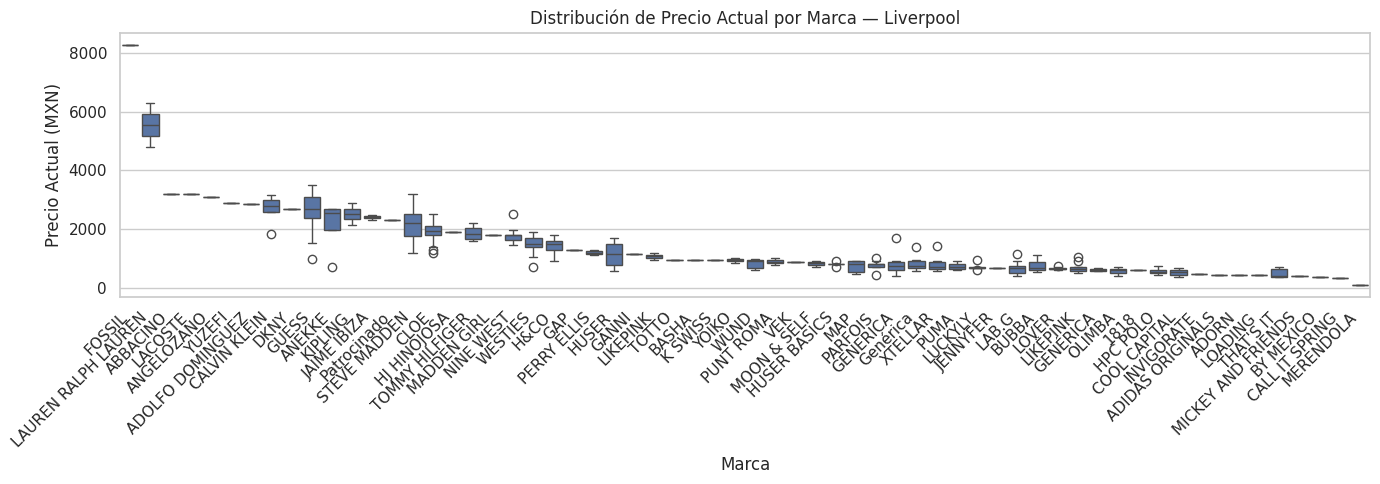

In [305]:
# Convertir precios a numérico (por si vienen como texto del CSV)
df_competencia['Precio actual']  = pd.to_numeric(df_competencia['Precio actual'],  errors='coerce')
df_competencia['Precio anterior'] = pd.to_numeric(df_competencia['Precio anterior'], errors='coerce')

plt.figure(figsize=(14, 5))
sns.boxplot(x='Marca', y='Precio actual', data=df_competencia,
            order=df_competencia.groupby('Marca')['Precio actual'].median().sort_values(ascending=False).index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Precio Actual por Marca — Liverpool')
plt.xlabel('Marca')
plt.ylabel('Precio Actual (MXN)')
plt.tight_layout()
plt.show()

2. Al igual que en los datos del retailer, por la naturaleza del proyecto y la información que conforma la base de datos, las pocas variables numericas no se utilizarán cómo típicamente (para validación o entrenamiento o pronóstico). **Su uso sera meramente para clasificación (rangos de precios).**

# Análisis de variables de texto

In [306]:
df_competencia.describe(include = 'object').T

,count,unique,top,freq
Marca,435,62,OLIMBA,56
Producto,435,271,Bolsa tote para mujer,42
Colores,426,161,Negro,86
Texto completo,435,435,YUZEFI | Bolsa crossbody Dinner Roll de piel p...,1


In [307]:
df_competencia.value_counts().to_frame()

count
Pagina Marca    Producto                                       Precio anterior Precio actual Colores                     Texto completo                                           
10     YUZEFI   Bolsa crossbody Dinner Roll de piel para mujer 3629.0          2903.2        Beige                       YUZEFI | Bolsa crossbody Dinner Roll de piel pa...      1
1      CLOE     Bolsa tote Gritylia para mujer                 1399.0          1399.0        Negro                       CLOE | Bolsa tote Gritylia para mujer | $1,3990...      1
                bolsa satchel cloe sirlania i para mujer       1999.0          1999.0        Negro | Azul | Beige        Y/o recibe 15% en monedero | CLOE | Bolsa satch...      1
                bolsa satchel cloe yelynia para mujer          2099.0          2099.0        Rosa | Camel | Amarillo     Y/o recibe 15% en monedero | CLOE | Bolsa satch...      1
       GENERICA Bolsa tote para mujer                          1099.0          550.0         Negro                       GENERICA | Bolsa tote para mujer | $1,09900 | $...      1
...                                                                                                                                                                            ...
       HPC POLO Bolsa crossbody para mujer                     699.0           449.0         Negro | Azul | Beige | Rosa HPC POLO | Bolsa crossbody para mujer | $69900 ...      1
       H&CO     set de bolsas tote h&co para mujer             1799.0          1799.0        Negro | Camel | Blanco      Y/o recibe 15% en monedero | H&CO | Set de bols...      1
                set de bolsas h&co para mujer                  1599.0          1599.0        Negro | Beige | Gris        Y/o recibe 15% en monedero | H&CO | Set de bols...      1
                                                                                             Beige | Negro               Y/o recibe 15% en monedero | H&CO | Set de bols...      1
       GUESS    Bolsa tote Meridian Ii para mujer              2990.0          2990.0        Negro                       GUESS | Bolsa tote Meridian Ii para mujer | $2,...      1

[426 rows x 1 columns]

In [308]:
for column in dfc:
    print(df_competencia[column].value_counts())
    print('-' * 50)

Marca
OLIMBA            56
H&CO              53
CLOE              48
GUESS             37
WESTIES           28
                  ..
Patrocinado        1
MADDEN GIRL        1
ABBACINO           1
CALL IT SPRING     1
YUZEFI             1
Name: count, Length: 62, dtype: int64
--------------------------------------------------
Producto
Bolsa tote para mujer                             42
Bolsa crossbody para mujer                        41
Bolsa satchel para mujer                          18
Bolsa hobo para mujer                              9
Bolsa shoulder para mujer                          7
                                                  ..
bolsa shoulder cloe de algod%C3%B3n para mujer     1
bolsa tote westies tabyna para mujer               1
bolsa tote cloe lildania para mujer                1
bolsa satchel cloe alasmi ii para mujer            1
Bolsa crossbody Hailey para mujer                  1
Name: count, Length: 271, dtype: int64
-------------------------------------------

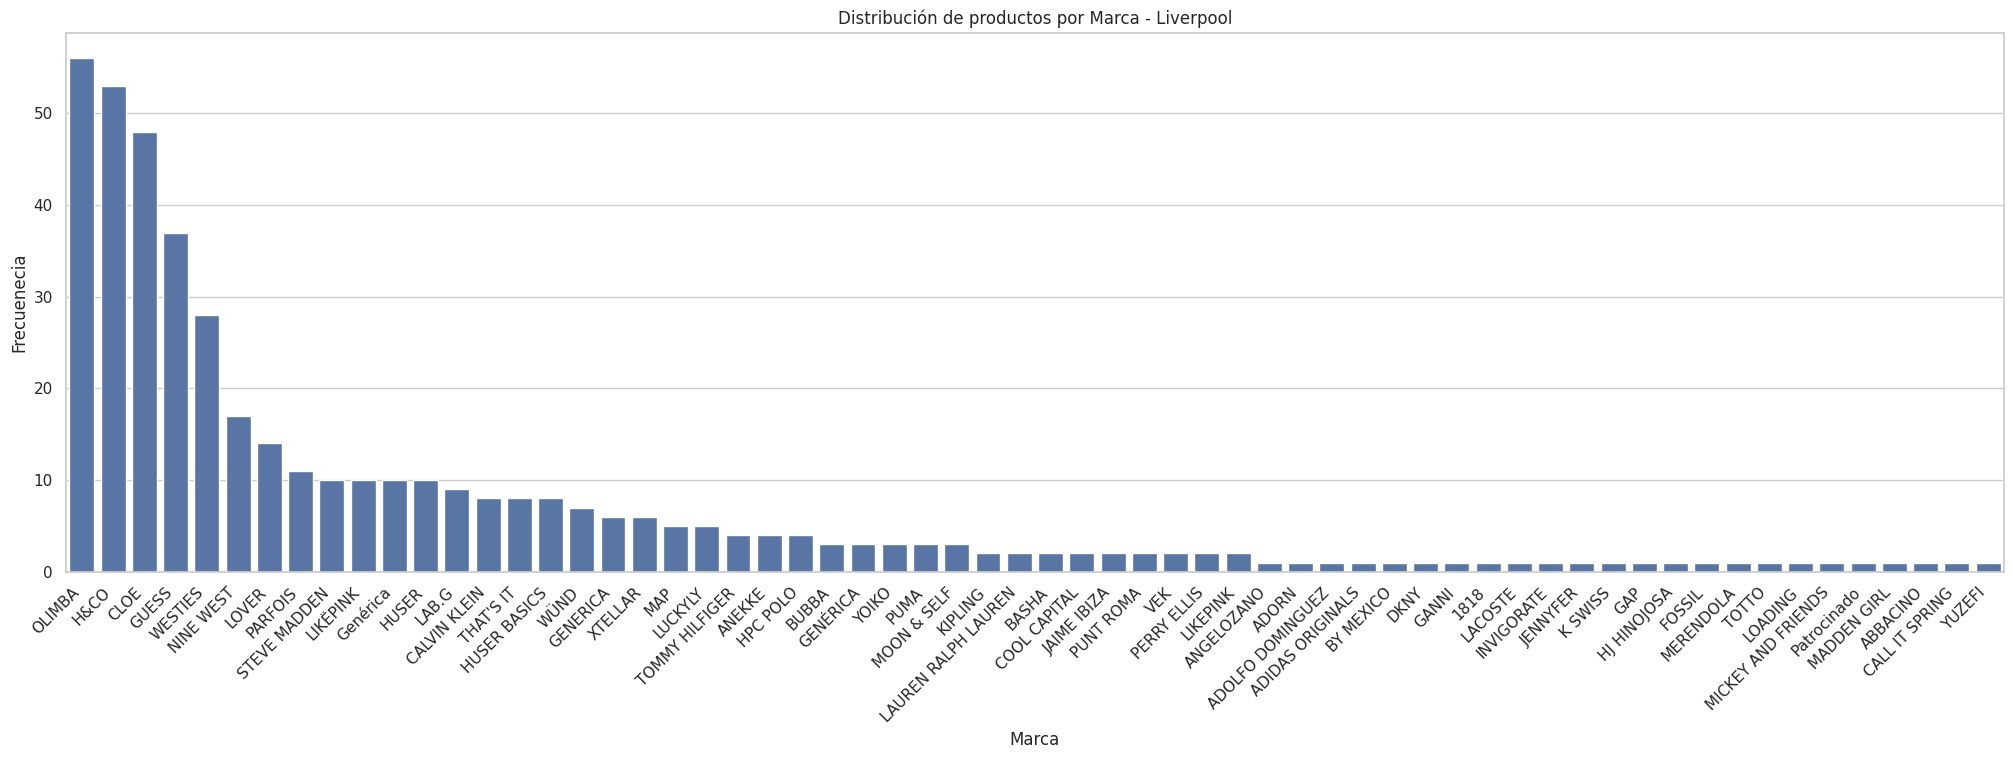

In [309]:
plt.figure(figsize=(25, 7))
sns.countplot(x='Marca', data=df_competencia, order=df_competencia['Marca'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de productos por Marca - Liverpool')
plt.ylabel('Frecuenecia')
plt.show()

2. Por la naturaleza del proyecto y la información que conforma la base de datos, las pocas variables numericas no se utilizarán cómo típicamente (para validación o entrenamiento o pronóstico). **Su uso sera meramente para clasificación (rangos de precios).**

# Análisis de correlación (bivariante y multivariante)

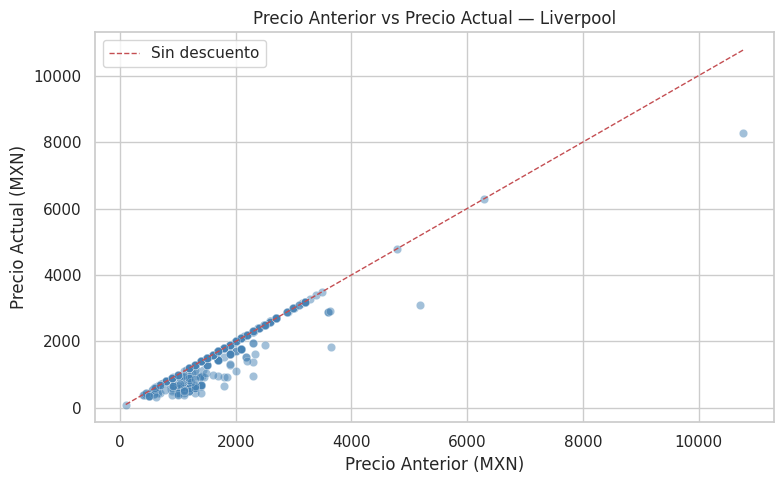

In [310]:
# Precio anterior vs Precio actual revela la relación de descuentos
plt.figure(figsize=(8, 5))
plt.scatter(df_competencia['Precio anterior'], df_competencia['Precio actual'],
            alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
plt.plot([df_competencia['Precio actual'].min(), df_competencia['Precio anterior'].max()],
         [df_competencia['Precio actual'].min(), df_competencia['Precio anterior'].max()],
         'r--', linewidth=1, label='Sin descuento')
plt.title('Precio Anterior vs Precio Actual — Liverpool')
plt.xlabel('Precio Anterior (MXN)')
plt.ylabel('Precio Actual (MXN)')
plt.legend()
plt.tight_layout()
plt.show()

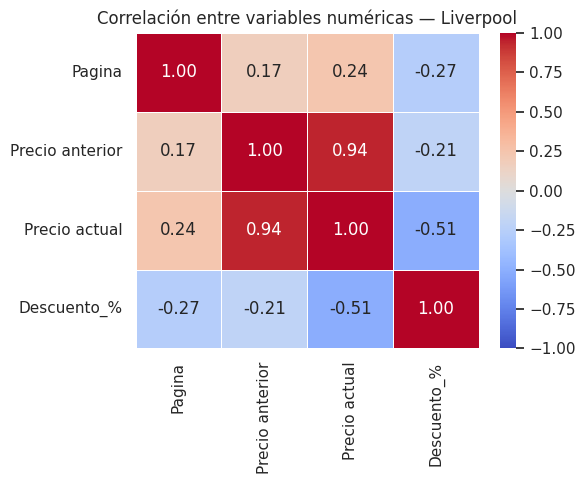

In [311]:
# Descuento porcentual como variable adicional
df_competencia['Descuento_%'] = ((df_competencia['Precio anterior'] - df_competencia['Precio actual'])
                                  / df_competencia['Precio anterior'] * 100).round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(round(df_competencia.corr(numeric_only=True), 2),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f')
plt.title('Correlación entre variables numéricas — Liverpool')
plt.tight_layout()
plt.show()

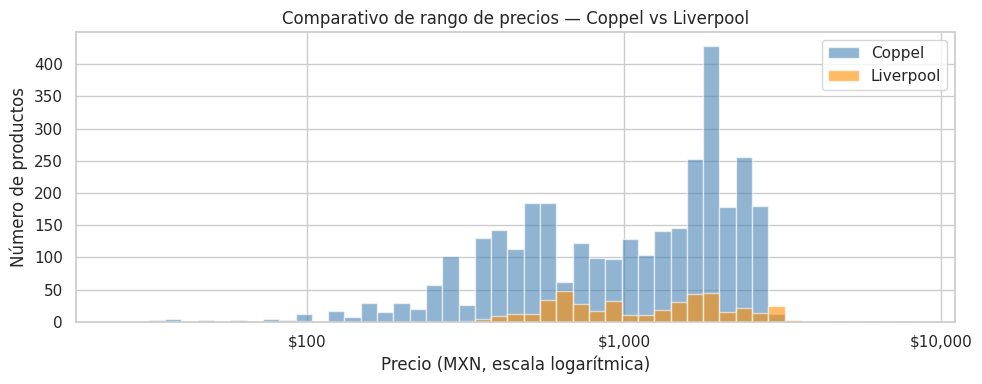

In [312]:
# Calcular el rango combinado de precios para definir bins uniformes en log
precio_min = min(df_retailer['Precio_final'].min(), df_competencia['Precio actual'].min())
precio_max = max(df_retailer['Precio_final'].max(), df_competencia['Precio actual'].max())

# Bins equidistantes en escala logarítmica
bins_log = np.logspace(np.log10(precio_min), np.log10(precio_max), 50)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_retailer['Precio_final'], bins=bins_log, alpha=0.6, label='Coppel', color='steelblue')
ax.hist(df_competencia['Precio actual'], bins=bins_log, alpha=0.6, label='Liverpool', color='darkorange')
ax.set_xscale('log')
ax.set_title('Comparativo de rango de precios — Coppel vs Liverpool')
ax.set_xlabel('Precio (MXN, escala logarítmica)')
ax.set_ylabel('Número de productos')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

4. Al igual que en los datos del retailer, el analisis bivariable y multivariable se vuelve poco relevante, ya que la naturaleza de la información relevante es la categorica. **En conclusión, el analísis exploratorio de los datos de la competencia permitió atender los registrios vacíos en columnas que eran relevantes y eliminar aquellas columnas que no lo eran.**

# Conclusiones

El proyecto se alimenta de dos bases de datos de productos: la del retailer "usuario" de la herramienta (en este caso Coppel) y la de los competidores más relevantes contra los que se busca hacer la comparativa.

Realizar este tipo de analisis exploratorios de la información base del proyecto nos sirve para identificar inconsistencias o resolver algunos detalles asociados a la disponibilidad y calidad de los datos. En ese sentido, particularmente sirvió para encontrar duplicidad de registros (distintos códigos con la misma descripción), rellenar celdas vacías (cuando el producto no tiene promoción), eliminar columnas que no agregan valor (ruido del scrapping), dar formato a los precios de la competencia (que originalmente son string, pero se necesita que sean int/float) y determinar un alcance inicial menor (bolsas) dada la distribución y consistencia de los datos.

A excepción de los precios (precio regular y precio de promoción), la mayor parte de la información relevante de los productos corresponde a datos en formato de texto (descripción, atributos, marca, etc.), por lo cual, en etapas posteriores de este proyecto, se estará trabajando con técnicas de REGEX y Vectorización (embeddings) para extraer las partes de dicho texto con el contenido semántico más relevante y así poder analizar la similitud entre productos.